# Feature Engineering - Application Data

This notebook creates new applicant-level financial risk features from the Home Credit application training dataset.

The objective is to convert raw borrower information into more meaningful credit risk indicators before improving the Probability of Default model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
app_train = pd.read_csv("../data/raw/application_train.csv")

app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df = app_train.copy()

df.shape

(307511, 122)

In [4]:
df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]

df[["AMT_CREDIT", "AMT_INCOME_TOTAL", "CREDIT_INCOME_RATIO"]].head()

,AMT_CREDIT,AMT_INCOME_TOTAL,CREDIT_INCOME_RATIO
0,406597.5,202500.0,2.007889
1,1293502.5,270000.0,4.790750
2,135000.0,67500.0,2.000000
3,312682.5,135000.0,2.316167
4,513000.0,121500.0,4.222222


In [5]:
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

df[["AMT_ANNUITY", "AMT_INCOME_TOTAL", "ANNUITY_INCOME_RATIO"]].head()

,AMT_ANNUITY,AMT_INCOME_TOTAL,ANNUITY_INCOME_RATIO
0,24700.5,202500.0,0.121978
1,35698.5,270000.0,0.132217
2,6750.0,67500.0,0.100000
3,29686.5,135000.0,0.219900
4,21865.5,121500.0,0.179963


In [6]:
df["CREDIT_ANNUITY_RATIO"] = df["AMT_CREDIT"] / df["AMT_ANNUITY"]

df[["AMT_CREDIT", "AMT_ANNUITY", "CREDIT_ANNUITY_RATIO"]].head()

,AMT_CREDIT,AMT_ANNUITY,CREDIT_ANNUITY_RATIO
0,406597.5,24700.5,16.461104
1,1293502.5,35698.5,36.234085
2,135000.0,6750.0,20.000000
3,312682.5,29686.5,10.532818
4,513000.0,21865.5,23.461618


In [7]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365

df[["DAYS_BIRTH", "AGE_YEARS"]].head()

,DAYS_BIRTH,AGE_YEARS
0,-9461,25.920548
1,-16765,45.931507
2,-19046,52.180822
3,-19005,52.068493
4,-19932,54.608219


In [8]:
df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED_CLEAN"] / 365

df[["DAYS_EMPLOYED", "DAYS_EMPLOYED_CLEAN", "EMPLOYMENT_YEARS"]].head()

,DAYS_EMPLOYED,DAYS_EMPLOYED_CLEAN,EMPLOYMENT_YEARS
0,-637,-637.0,1.745205
1,-1188,-1188.0,3.254795
2,-225,-225.0,0.616438
3,-3039,-3039.0,8.326027
4,-3038,-3038.0,8.323288


In [9]:
df["EMPLOYMENT_AGE_RATIO"] = df["EMPLOYMENT_YEARS"] / df["AGE_YEARS"]

df[["EMPLOYMENT_YEARS", "AGE_YEARS", "EMPLOYMENT_AGE_RATIO"]].head()

,EMPLOYMENT_YEARS,AGE_YEARS,EMPLOYMENT_AGE_RATIO
0,1.745205,25.920548,0.067329
1,3.254795,45.931507,0.070862
2,0.616438,52.180822,0.011814
3,8.326027,52.068493,0.159905
4,8.323288,54.608219,0.152418


In [10]:
df["INCOME_PER_FAMILY_MEMBER"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]

df[["AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS", "INCOME_PER_FAMILY_MEMBER"]].head()

,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,INCOME_PER_FAMILY_MEMBER
0,202500.0,1.0,202500.0
1,270000.0,2.0,135000.0
2,67500.0,1.0,67500.0
3,135000.0,2.0,67500.0
4,121500.0,1.0,121500.0


In [11]:
df["INCOME_PER_CHILD"] = df["AMT_INCOME_TOTAL"] / (df["CNT_CHILDREN"] + 1)

df[["AMT_INCOME_TOTAL", "CNT_CHILDREN", "INCOME_PER_CHILD"]].head()

,AMT_INCOME_TOTAL,CNT_CHILDREN,INCOME_PER_CHILD
0,202500.0,0,202500.0
1,270000.0,0,270000.0
2,67500.0,0,67500.0
3,135000.0,0,135000.0
4,121500.0,0,121500.0


In [12]:
external_score_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

df["EXT_SOURCE_MEAN"] = df[external_score_cols].mean(axis=1)

df[external_score_cols + ["EXT_SOURCE_MEAN"]].head()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_MEAN
0,0.083037,0.262949,0.139376,0.161787
1,0.311267,0.622246,NaN,0.466757
2,NaN,0.555912,0.729567,0.642739
3,NaN,0.650442,NaN,0.650442
4,NaN,0.322738,NaN,0.322738


In [13]:
document_cols = [col for col in df.columns if col.startswith("FLAG_DOCUMENT")]

df["DOCUMENT_COUNT"] = df[document_cols].sum(axis=1)

df[document_cols + ["DOCUMENT_COUNT"]].head()

,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,...,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,DOCUMENT_COUNT
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [14]:
engineered_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "EMPLOYMENT_AGE_RATIO",
    "INCOME_PER_FAMILY_MEMBER",
    "INCOME_PER_CHILD",
    "EXT_SOURCE_MEAN",
    "DOCUMENT_COUNT"
]

df[engineered_features].head()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,AGE_YEARS,EMPLOYMENT_YEARS,EMPLOYMENT_AGE_RATIO,INCOME_PER_FAMILY_MEMBER,INCOME_PER_CHILD,EXT_SOURCE_MEAN,DOCUMENT_COUNT
0,2.007889,0.121978,16.461104,25.920548,1.745205,0.067329,202500.0,202500.0,0.161787,1
1,4.790750,0.132217,36.234085,45.931507,3.254795,0.070862,135000.0,270000.0,0.466757,1
2,2.000000,0.100000,20.000000,52.180822,0.616438,0.011814,67500.0,67500.0,0.642739,0
3,2.316167,0.219900,10.532818,52.068493,8.326027,0.159905,67500.0,135000.0,0.650442,1
4,4.222222,0.179963,23.461618,54.608219,8.323288,0.152418,121500.0,121500.0,0.322738,1


In [15]:
df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,8.473684e+01
ANNUITY_INCOME_RATIO,307499.0,0.180930,0.094574,0.000224,0.114782,0.162833,0.229067,1.875965e+00
CREDIT_ANNUITY_RATIO,307499.0,21.612322,7.823823,8.036674,15.614496,20.000000,27.099985,4.530508e+01
AGE_YEARS,307511.0,43.936973,11.956133,20.517808,34.008219,43.150685,53.923288,6.912055e+01
EMPLOYMENT_YEARS,252137.0,6.531971,6.406466,-0.000000,2.101370,4.515068,8.698630,4.907397e+01
EMPLOYMENT_AGE_RATIO,252137.0,0.156861,0.133549,-0.000000,0.056099,0.118733,0.219170,7.288115e-01
INCOME_PER_FAMILY_MEMBER,307509.0,93105.879645,101373.363394,2812.500000,47250.000000,75000.000000,112500.000000,3.900000e+07
INCOME_PER_CHILD,307511.0,139507.940778,145811.035192,3000.000000,78750.000000,117000.000000,180000.000000,5.850000e+07
EXT_SOURCE_MEAN,307339.0,0.509251,0.149802,0.000006,0.413648,0.524502,0.622819,8.789034e-01
DOCUMENT_COUNT,307511.0,0.930155,0.344295,0.000000,1.000000,1.000000,1.000000,4.000000e+00


In [16]:
target = "TARGET"

engineered_corr = df[engineered_features + [target]].corr()[target].sort_values(ascending=False)

engineered_corr

TARGET                      1.000000
DOCUMENT_COUNT              0.017193
ANNUITY_INCOME_RATIO        0.014265
INCOME_PER_FAMILY_MEMBER   -0.006571
CREDIT_INCOME_RATIO        -0.007727
INCOME_PER_CHILD           -0.012529
CREDIT_ANNUITY_RATIO       -0.032102
EMPLOYMENT_AGE_RATIO       -0.067955
EMPLOYMENT_YEARS           -0.074958
AGE_YEARS                  -0.078239
EXT_SOURCE_MEAN            -0.222052
Name: TARGET, dtype: float64

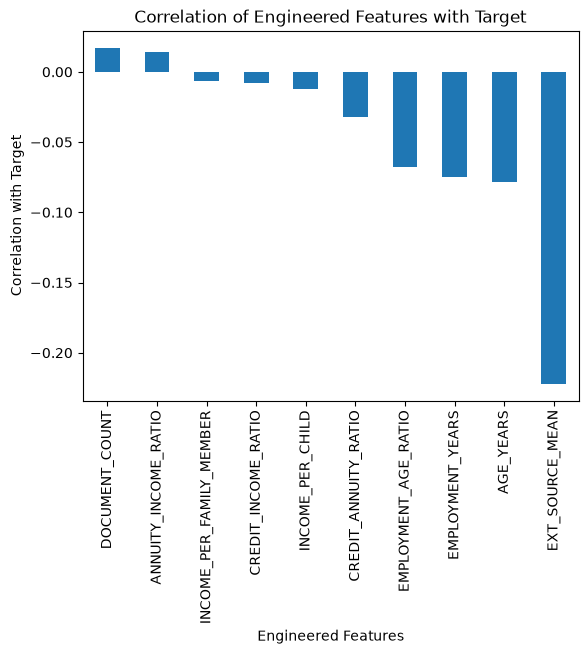

In [17]:
engineered_corr.drop(target).plot(kind="bar")

plt.title("Correlation of Engineered Features with Target")
plt.xlabel("Engineered Features")
plt.ylabel("Correlation with Target")
plt.show()

In [18]:
df.to_csv("../data/processed/application_train_feature_engineered.csv", index=False)

## Feature Engineering Business Observations

This notebook created new financial and risk-related features from the raw application data.

Important engineered features include:

- Credit-to-income ratio
- Annuity-to-income ratio
- Credit-to-annuity ratio
- Applicant age in years
- Employment duration in years
- Employment-to-age ratio
- Income per family member
- External score average
- Document count

These features help convert raw application data into more meaningful borrower risk indicators.

The next step is to rebuild the Probability of Default model using these engineered features and compare performance with the baseline model.